In [1]:
# Cell 1: Mount Google Drive, import libraries, and set the output path

from google.colab import drive
drive.mount('/content/drive')

import os, time, re, requests, json
import pandas as pd
import numpy as np
from datetime import datetime

OUT = '/content/drive/MyDrive/Thesis Project_Keyu/steam_thesis'
os.makedirs(OUT, exist_ok=True)
print(f'Workspace: {OUT}')

Mounted at /content/drive
Workspace: /content/drive/MyDrive/Thesis Project_Keyu/steam_thesis


In [2]:
# Cell 2: Define the 25-game list and the Steam-reviews collection function

# 25 games across genre clusters (pre-filtering).
# Final analysis sample is determined by data-quality criteria in Cell 7 / Cell 9,
# fixed BEFORE viewing any event-study results.
GAMES = {
    # ----- original 10 -----
    730:     ('Counter-Strike 2',     250000),
    578080:  ('PUBG Battlegrounds',   100000),
    1172470: ('Apex Legends',          80000),
    381210:  ('Dead by Daylight',      80000),
    739630:  ('Phasmophobia',          30000),
    275850:  ('No Mans Sky',           50000),
    230410:  ('Warframe',              50000),
    570:     ('Dota 2',               150000),
    252490:  ('Rust',                   60000),
    440:     ('Team Fortress 2',       60000),
    # ----- batch 2 (6) -----
    553850:  ('Helldivers 2',          80000),
    105600:  ('Terraria',              50000),
    236390:  ('War Thunder',           80000),
    1091500: ('Cyberpunk 2077',        60000),
    1086940: ('Baldurs Gate 3',        60000),
    548430:  ('Deep Rock Galactic',    40000),
    # ----- batch 3 (9) -----
    526870:  ('Satisfactory',          60000),
    2694490: ('Path of Exile 2',       80000),
    1623730: ('Palworld',              60000),
    892970:  ('Valheim',               50000),
    1145350: ('Hades II',              50000),
    1030300: ('Hollow Knight Silksong', 60000),
    1794680: ('Vampire Survivors',     40000),
    413150:  ('Stardew Valley',        50000),
    1326470: ('Sons of the Forest',    40000),
}

# --- Reviews collection function ---
def get_reviews(appid, name, limit):
    """Paginate Steam Store Reviews API in reverse chronological order."""
    url = f'https://store.steampowered.com/appreviews/{appid}'
    cursor = '*'
    results = []
    print(f'[{name}] target: {limit:,}')

    while len(results) < limit:
        params = {
            'json': 1, 'filter': 'recent', 'language': 'all',
            'num_per_page': 100, 'cursor': cursor,
            'purchase_type': 'all', 'review_type': 'all',
        }
        try:
            r = requests.get(url, params=params, timeout=30)
            data = r.json()
        except Exception as e:
            print(f'  error: {e}, retrying...')
            time.sleep(10)
            continue

        reviews = data.get('reviews', [])
        if not reviews:
            break

        for rv in reviews:
            a = rv.get('author', {})
            results.append({
                'appid': appid, 'game': name,
                'review_id': rv.get('recommendationid'),
                'steamid': a.get('steamid'),
                'playtime_forever': a.get('playtime_forever', 0),
                'playtime_at_review': a.get('playtime_at_review', 0),
                'num_games_owned': a.get('num_games_owned', 0),
                'num_reviews': a.get('num_reviews', 0),
                'language': rv.get('language'),
                'review': rv.get('review'),
                'voted_up': rv.get('voted_up'),
                'votes_up': rv.get('votes_up', 0),
                'votes_funny': rv.get('votes_funny', 0),
                'comment_count': rv.get('comment_count', 0),
                'score': rv.get('weighted_vote_score', 0),
                'steam_purchase': rv.get('steam_purchase'),
                'received_for_free': rv.get('received_for_free'),
                'early_access': rv.get('written_during_early_access'),
                'timestamp_created': rv.get('timestamp_created'),
                'timestamp_updated': rv.get('timestamp_updated'),
            })

        new_cursor = data.get('cursor')
        if new_cursor == cursor:
            break
        cursor = new_cursor

        if len(results) % 10000 < 100:
            print(f'  {len(results):,} collected...')
        time.sleep(1.2)

    print(f'  done: {len(results):,}')
    return results

total = sum(v[1] for v in GAMES.values())
print(f'{len(GAMES)} games configured, {total:,} target reviews (pre-filter)')

25 games configured, 1,770,000 target reviews (pre-filter)


In [3]:
# Cell 3: Collect reviews for every game (skips any reviews_*.csv already on Drive)

for appid, (name, limit) in GAMES.items():
    save_path = f'{OUT}/reviews_{appid}.csv'
    if os.path.exists(save_path):
        print(f'[{name}] exists, skipping')
        continue
    reviews = get_reviews(appid, name, limit)
    pd.DataFrame(reviews).to_csv(save_path, index=False)
    print(f'  saved: reviews_{appid}.csv ({len(reviews):,} rows)\n')

print('All reviews collected.')

[Counter-Strike 2] exists, skipping
[PUBG Battlegrounds] exists, skipping
[Apex Legends] exists, skipping
[Dead by Daylight] exists, skipping
[Phasmophobia] exists, skipping
[No Mans Sky] exists, skipping
[Warframe] exists, skipping
[Dota 2] exists, skipping
[Rust] exists, skipping
[Team Fortress 2] exists, skipping
[Helldivers 2] exists, skipping
[Terraria] exists, skipping
[War Thunder] exists, skipping
[Cyberpunk 2077] exists, skipping
[Baldurs Gate 3] exists, skipping
[Deep Rock Galactic] exists, skipping
[Satisfactory] exists, skipping
[Path of Exile 2] exists, skipping
[Palworld] exists, skipping
[Valheim] exists, skipping
[Hades II] exists, skipping
[Hollow Knight Silksong] exists, skipping
[Vampire Survivors] exists, skipping
[Stardew Valley] exists, skipping
[Sons of the Forest] exists, skipping
All reviews collected.


In [4]:
# Cell 4: Collect patch notes / news for every game (overwrites news_raw.csv)

# --- News fetch function (Steam News API) ---
def get_news(appid, name, count=500):
    """Fetch news/patch notes via Steam News API."""
    url = 'https://api.steampowered.com/ISteamNews/GetNewsForApp/v2/'
    params = {'appid': appid, 'count': count, 'maxlength': 0, 'format': 'json'}
    try:
        r = requests.get(url, params=params, timeout=30)
        items = r.json().get('appnews', {}).get('newsitems', [])
    except Exception as e:
        print(f'  [{name}] failed: {e}')
        return []
    results = []
    for item in items:
        results.append({
            'appid': appid, 'game': name,
            'news_id': item.get('gid'), 'title': item.get('title'),
            'contents': item.get('contents'), 'url': item.get('url'),
            'author': item.get('author'), 'feedlabel': item.get('feedlabel'),
            'feedname': item.get('feedname'),
            'tags': ','.join(item.get('tags', [])),
            'timestamp': item.get('date'),
        })
    print(f'  [{name}] {len(results)} items')
    return results

# --- Fetch for all games and save ---
all_news = []
for appid, (name, _) in GAMES.items():
    all_news.extend(get_news(appid, name))
    time.sleep(1)

df_news = pd.DataFrame(all_news)
df_news.to_csv(f'{OUT}/news_raw.csv', index=False)
print(f'\nSaved: news_raw.csv ({len(df_news)} items)')
print(df_news.game.value_counts())

  [Counter-Strike 2] 500 items
  [PUBG Battlegrounds] 500 items
  [Apex Legends] 500 items
  [Dead by Daylight] 500 items
  [Phasmophobia] 364 items
  [No Mans Sky] 500 items
  [Warframe] 500 items
  [Dota 2] 500 items
  [Rust] 500 items
  [Team Fortress 2] 500 items
  [Helldivers 2] 500 items
  [Terraria] 446 items
  [War Thunder] 500 items
  [Cyberpunk 2077] 500 items
  [Baldurs Gate 3] 500 items
  [Deep Rock Galactic] 500 items
  [Satisfactory] 310 items
  [Path of Exile 2] 230 items
  [Palworld] 388 items
  [Valheim] 343 items
  [Hades II] 120 items
  [Hollow Knight Silksong] 138 items
  [Vampire Survivors] 269 items
  [Stardew Valley] 500 items
  [Sons of the Forest] 214 items

Saved: news_raw.csv (10322 items)
game
Counter-Strike 2          500
PUBG Battlegrounds        500
Apex Legends              500
Dead by Daylight          500
No Mans Sky               500
Dota 2                    500
Warframe                  500
Rust                      500
Team Fortress 2           500

In [5]:
# Cell 5: Collect monthly CCU as a supplementary signal (overwrites ccu_raw.csv)

# --- CCU fetch function (steamcharts) ---
def get_ccu(appid, name):
    """Fetch monthly average player counts from steamcharts."""
    url = f'https://steamcharts.com/app/{appid}/chart-data.json'
    headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7)'}
    try:
        r = requests.get(url, headers=headers, timeout=15)
        if r.status_code != 200:
            print(f'  [{name}] HTTP {r.status_code}')
            return []
        data = r.json()
    except Exception as e:
        print(f'  [{name}] failed: {e}')
        return []
    results = []
    for point in data:
        ts = point[0] / 1000
        results.append({
            'appid': appid, 'game': name,
            'timestamp': int(ts),
            'date': datetime.utcfromtimestamp(ts).strftime('%Y-%m-%d'),
            'avg_players': point[1],
        })
    print(f'  [{name}] {len(results)} points')
    return results

# --- Fetch for all games and save ---
all_ccu = []
for appid, (name, _) in GAMES.items():
    all_ccu.extend(get_ccu(appid, name))
    time.sleep(3)

if all_ccu:
    pd.DataFrame(all_ccu).to_csv(f'{OUT}/ccu_raw.csv', index=False)
    print(f'Saved: ccu_raw.csv ({len(all_ccu)} points)')
else:
    print('CCU failed — using review volume as proxy')

  [Counter-Strike 2] 945 points


/tmp/ipykernel_1692/1652190844.py:23: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  'date': datetime.utcfromtimestamp(ts).strftime('%Y-%m-%d'),


  [PUBG Battlegrounds] 890 points
  [Apex Legends] 845 points
  [Dead by Daylight] 898 points
  [Phasmophobia] 847 points
  [No Mans Sky] 896 points
  [Warframe] 939 points
  [Dota 2] 945 points
  [Rust] 928 points
  [Team Fortress 2] 945 points
  [Helldivers 2] 806 points
  [Terraria] 945 points
  [War Thunder] 936 points
  [Cyberpunk 2077] 844 points
  [Baldurs Gate 3] 846 points
  [Deep Rock Galactic] 892 points
  [Satisfactory] 850 points
  [Path of Exile 2] 796 points
  [Palworld] 807 points
  [Valheim] 842 points
  [Hades II] 803 points
  [Hollow Knight Silksong] 787 points
  [Vampire Survivors] 833 points
  [Stardew Valley] 904 points
  [Sons of the Forest] 818 points
Saved: ccu_raw.csv (21787 points)


In [6]:
# Cell 6: Merge per-game review files, dedup, filter, clean text -> reviews_clean.csv

review_files = [f for f in os.listdir(OUT)
                if f.startswith('reviews_') and f.endswith('.csv')
                and f not in ('reviews_clean.csv', 'reviews_sentiment.csv')]
dfs = [pd.read_csv(f'{OUT}/{f}') for f in sorted(review_files)]
for f, d in zip(sorted(review_files), dfs):
    print(f'{f}: {len(d):,}')
df = pd.concat(dfs, ignore_index=True)
print(f'\nMerged: {len(df):,}')

# time features
df['date'] = pd.to_datetime(df['timestamp_created'], unit='s', utc=True)
df['date_str'] = df['date'].dt.strftime('%Y-%m-%d')
df['year_month'] = df['date'].dt.strftime('%Y-%m')
df['day_of_week'] = df['date'].dt.dayofweek

# dedup
n0 = len(df)
df = df.sort_values('timestamp_created').drop_duplicates(subset=['steamid', 'appid'], keep='last')
print(f'Dedup: {n0:,} -> {len(df):,}')

# playtime filter
df = df[df['playtime_forever'] >= 30]
print(f'Playtime filter: {len(df):,}')

# text features
df['review_len'] = df['review'].astype(str).str.len()
df['review_words'] = df['review'].astype(str).str.split().str.len()
df['is_english'] = df['language'] == 'english'

# text cleaning (fix VADER misclassification from Steam ♥ censorship)
def clean_text(text):
    text = str(text)
    text = re.sub(r'♥+', '', text)
    text = re.sub(r'\[/?[a-zA-Z0-9_]+\]', '', text)
    text = re.sub(r'https?://\S+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['review_cleaned'] = df['review'].apply(clean_text)
df.to_csv(f'{OUT}/reviews_clean.csv', index=False)
print('Saved: reviews_clean.csv')

# coverage check
print('\n' + '=' * 60)
print(f'COVERAGE CHECK ({df["game"].nunique()} games)')
print('=' * 60)
for game in sorted(df['game'].unique()):
    g = df[df['game'] == game]
    eng = g[g['is_english']]
    n_days = g['date_str'].nunique()
    eng_daily = len(eng) / max(n_days, 1)
    print(f'\n  {game}')
    print(f'    reviews:    {len(g):,} total / {len(eng):,} english ({len(eng)/len(g)*100:.0f}%)')
    print(f'    date range: {g["date_str"].min()} ~ {g["date_str"].max()} ({n_days} days)')
    print(f'    eng/day:    {eng_daily:.1f}')
    print(f'    pos rate:   {g["voted_up"].mean()*100:.1f}%')

reviews_1030300.csv: 60,092
reviews_105600.csv: 50,094
reviews_1086940.csv: 60,095
reviews_1091500.csv: 60,085
reviews_1145350.csv: 50,094
reviews_1172470.csv: 80,094
reviews_1326470.csv: 40,096
reviews_1623730.csv: 60,095
reviews_1794680.csv: 40,097
reviews_230410.csv: 50,092
reviews_236390.csv: 80,094
reviews_252490.csv: 60,096
reviews_2694490.csv: 80,090
reviews_275850.csv: 50,093
reviews_381210.csv: 80,058
reviews_413150.csv: 50,092
reviews_440.csv: 44,691
reviews_526870.csv: 60,094
reviews_548430.csv: 17,296
reviews_553850.csv: 80,081
reviews_570.csv: 150,018
reviews_578080.csv: 100,091
reviews_730.csv: 164,061
reviews_739630.csv: 30,099
reviews_892970.csv: 50,093

Merged: 1,647,981
Dedup: 1,647,981 -> 1,647,981
Playtime filter: 1,639,667
Saved: reviews_clean.csv

COVERAGE CHECK (25 games)

  Apex Legends
    reviews:    79,473 total / 30,126 english (38%)
    date range: 2025-05-05 ~ 2026-05-31 (392 days)
    eng/day:    76.9
    pos rate:   66.5%

  Baldurs Gate 3
    reviews:  

In [7]:
# Cell 7: Pre-registered data-quality screening (part 1 of 2)
# Thresholds fixed BEFORE viewing any event-study results, to avoid selection on outcomes.
#   eng/day >= 60  | coverage >= 130 days | vader_gap >= 0.40  (clean-ratio added in Cell 9)

!pip install vaderSentiment -q
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
_an = SentimentIntensityAnalyzer()

df = pd.read_csv(f'{OUT}/reviews_clean.csv')

rows = []
for game in sorted(df['game'].unique()):
    g = df[df['game'] == game]
    eng = g[g['is_english']].copy()
    n_days = g['date_str'].nunique()
    eng_per_day = len(eng) / max(n_days, 1)

    sample = eng.dropna(subset=['review_cleaned'])
    sample = sample[sample['review_cleaned'].astype(str).str.len() >= 10]
    if len(sample) > 5000:
        sample = sample.sample(5000, random_state=42)
    s = sample['review_cleaned'].astype(str).apply(lambda x: _an.polarity_scores(x)['compound'])
    pos = s[sample['voted_up'] == True].mean()
    neg = s[sample['voted_up'] == False].mean()
    gap = (pos - neg) if (pd.notna(pos) and pd.notna(neg)) else 0

    rows.append({'game': game, 'eng_per_day': round(eng_per_day, 1),
                 'coverage_days': n_days, 'vader_gap': round(gap, 3)})

qual = pd.DataFrame(rows)
qual.to_csv(f'{OUT}/quality_screening.csv', index=False)

print('=' * 70)
print('DATA QUALITY SCREENING (part 1: eng/day, coverage, vader_gap)')
print('=' * 70)
print(qual.to_string(index=False))
print('\nNOTE: clean-event ratio added in Cell 9 after the event table is built.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.3 MB/s eta 0:00:00
DATA QUALITY SCREENING (part 1: eng/day, coverage, vader_gap)
                  game  eng_per_day  coverage_days  vader_gap
          Apex Legends         76.9            392      0.463
        Baldurs Gate 3        115.3            253      0.475
      Counter-Strike 2        657.2             66      0.426
        Cyberpunk 2077        117.3            216      0.480
      Dead by Daylight        121.8            269      0.470
    Deep Rock Galactic         36.8            188      0.415
                Dota 2        102.2            208      0.425
              Hades II        107.6            262      0.504
          Helldivers 2        222.0            227      0.443
Hollow Knight Silksong        117.7            197      0.590
           No Mans Sky         84.5            277      0.542
    PUBG Battlegrounds         56.4            201      0.472
              Palworld         51.0            492  

In [8]:
# Cell 8: Classify update types and build the event table -> update_events.csv
# Expanded keywords to cover new games (warbond, stratagem, phantom liberty, etc.)
# Seasonal excluded from main analysis (too few events for reliable inference)

df_news = pd.read_csv(f'{OUT}/news_raw.csv')

official = ['Community Announcements', 'SteamDB', 'Announcement']
df_patches = df_news[df_news['feedlabel'].isin(official)].copy()
print(f'Official posts: {len(df_patches)} / {len(df_news)} total')

def classify_update(title, contents):
    text = f'{title} {contents}'.lower()

    major_kw = ['new map', 'new character', 'new killer', 'new survivor',
                'new weapon', 'new mode', 'new chapter', 'new biome',
                'new feature', 'major update', 'content update',
                'expansion', 'dlc', 'new boss', 'new area', 'new quest',
                'new agent', 'new legend', 'rework', 'overhaul', 'revamp',
                'new operation', 'new season', 'season launch', 'chapter',
                'new warframe', 'prime access', 'new hero', 'battle pass',
                'new expedition', 'new dungeon', 'new story', 'new vehicle',
                'warbond', 'new stratagem', 'phantom liberty',
                'new class', 'new act', 'new enemy']
    if any(kw in text for kw in major_kw):
        return 'major_content'

    balance_kw = ['balance', 'nerf', 'buff', 'adjust', 'tuning',
                  'recoil', 'hitbox', 'cooldown', 'matchmaking',
                  'ranked', 'mmr', 'weapon stats', 'perk', 'meta',
                  'damage changed', 'movement speed', 'ability changed',
                  'economy', 'repair cost']
    if any(kw in text for kw in balance_kw):
        return 'balance'

    maint_kw = ['fix', 'bug', 'crash', 'hotfix', 'stability',
                'performance', 'optimization', 'server', 'anti-cheat',
                'vac', 'exploit', 'glitch', 'resolved', 'addressed',
                'corrected', 'patch', 'update', 'compatibility']
    if any(kw in text for kw in maint_kw):
        return 'maintenance'

    seasonal_kw = ['halloween', 'christmas', 'holiday', 'winter event',
                   'summer event', 'lunar new year', 'valentine',
                   'anniversary', 'limited time', 'festive']
    if any(kw in text for kw in seasonal_kw):
        return 'seasonal'

    return 'other'

df_patches['update_type'] = df_patches.apply(
    lambda r: classify_update(str(r['title']), str(r['contents'])), axis=1
)

print('\nClassification distribution:')
print(df_patches['update_type'].value_counts())

# magnitude features
df_patches['word_count'] = df_patches['contents'].astype(str).str.split().str.len()
df_patches['log_magnitude'] = np.log1p(df_patches['word_count'])
df_patches['date'] = pd.to_datetime(df_patches['timestamp'], unit='s', utc=True)
df_patches['date_str'] = df_patches['date'].dt.strftime('%Y-%m-%d')

# exclude other and seasonal, collapse same-day events
df_events = df_patches[~df_patches['update_type'].isin(['other', 'seasonal'])].copy()
df_events = df_events.sort_values('word_count', ascending=False)
df_events = df_events.drop_duplicates(subset=['game', 'date_str'], keep='first')
df_events = df_events.sort_values(['game', 'timestamp']).reset_index(drop=True)

print(f'\nUpdate events: {len(df_events)}')
print(df_events.groupby(['game', 'update_type']).size().unstack(fill_value=0))

df_events.to_csv(f'{OUT}/update_events.csv', index=False)
print('\nSaved: update_events.csv')

Official posts: 5455 / 10322 total

Classification distribution:
update_type
maintenance      1658
major_content    1470
other            1347
balance           778
seasonal          202
Name: count, dtype: int64

Update events: 3332
update_type             balance  maintenance  major_content
game                                                       
Apex Legends                 59           60            104
Baldurs Gate 3                3           14             12
Counter-Strike 2            100          150             16
Cyberpunk 2077                2            4             25
Dead by Daylight             51           20            117
Deep Rock Galactic           59          151            136
Dota 2                       76          104             52
Hades II                      6            8             17
Helldivers 2                 18           22             53
Hollow Knight Silksong        0            5              1
No Mans Sky                  12           33  

In [9]:
# Cell 9: Finalize the analysis sample (part 2 of 2) -> analysis_games.csv
# Combines all four pre-registered criteria; analysis_games.csv is read by the event-study cells below.

qual = pd.read_csv(f'{OUT}/quality_screening.csv')
df_events = pd.read_csv(f'{OUT}/update_events.csv')

# clean-event ratio per game (events >3 days after the previous one)
df_events = df_events.sort_values(['game', 'timestamp'])
df_events['date_dt'] = pd.to_datetime(df_events['date_str'])
df_events['days_since_last'] = df_events.groupby('game')['date_dt'].diff().dt.days.fillna(999)
df_events['is_clean'] = df_events['days_since_last'] > 3
clean_ratio = df_events.groupby('game')['is_clean'].mean().rename('clean_ratio').reset_index()

qual = qual.merge(clean_ratio, on='game', how='left')
qual['clean_ratio'] = qual['clean_ratio'].fillna(0)

# pre-registered thresholds (stricter set)
T = dict(eng_per_day=60, coverage_days=130, clean_ratio=0.25, vader_gap=0.40)
qual['pass'] = (
    (qual['eng_per_day']   >= T['eng_per_day']) &
    (qual['coverage_days'] >= T['coverage_days']) &
    (qual['clean_ratio']   >= T['clean_ratio']) &
    (qual['vader_gap']     >= T['vader_gap'])
)

def reasons(r):
    out = []
    if r['eng_per_day']   < T['eng_per_day']:   out.append(f"eng/day {r['eng_per_day']}")
    if r['coverage_days'] < T['coverage_days']: out.append(f"coverage {r['coverage_days']}d")
    if r['clean_ratio']   < T['clean_ratio']:   out.append(f"clean {r['clean_ratio']:.0%}")
    if r['vader_gap']     < T['vader_gap']:      out.append(f"gap {r['vader_gap']}")
    return '; '.join(out) if out else 'PASS'
qual['fail_reason'] = qual.apply(reasons, axis=1)
qual = qual.sort_values(['pass', 'eng_per_day'], ascending=[False, False])

print('=' * 70)
print(f"FINAL SCREENING  (eng>={T['eng_per_day']}/day, cov>={T['coverage_days']}d, "
      f"clean>={T['clean_ratio']:.0%}, gap>={T['vader_gap']})")
print('=' * 70)
print(qual.to_string(index=False))
print(f"\nPASS: {qual['pass'].sum()}  |  EXCLUDED: {(~qual['pass']).sum()}")
print('\nExcluded games:')
for _, r in qual[~qual['pass']].iterrows():
    print(f"  {r['game']:<28} {r['fail_reason']}")

qual.to_csv(f'{OUT}/quality_screening.csv', index=False)
qual[qual['pass']][['game']].to_csv(f'{OUT}/analysis_games.csv', index=False)
print('\nSaved: analysis_games.csv (used by Event Study)')

FINAL SCREENING  (eng>=60/day, cov>=130d, clean>=25%, gap>=0.4)
                  game  eng_per_day  coverage_days  vader_gap  clean_ratio  pass             fail_reason
          Helldivers 2        222.0            227      0.443     0.784946  True                    PASS
      Dead by Daylight        121.8            269      0.470     0.675532  True                    PASS
                  Rust        120.7            135      0.425     0.884615  True                    PASS
Hollow Knight Silksong        117.7            197      0.590     1.000000  True                    PASS
        Stardew Valley        117.4            149      0.632     0.808511  True                    PASS
        Cyberpunk 2077        117.3            216      0.480     0.774194  True                    PASS
        Baldurs Gate 3        115.3            253      0.475     1.000000  True                    PASS
       Team Fortress 2        111.3            182      0.422     0.642857  True                

In [10]:
# Cell 10: Score all English reviews with VADER -> reviews_sentiment.csv

analyzer = SentimentIntensityAnalyzer()

df = pd.read_csv(f'{OUT}/reviews_clean.csv')
df_eng = df[df['is_english']].copy()
df_eng = df_eng[df_eng['review_cleaned'].astype(str).str.len() >= 10]
print(f'English reviews to score: {len(df_eng):,}')

scores = []
for i in range(0, len(df_eng), 10000):
    chunk = df_eng.iloc[i:i+10000]
    s = chunk['review_cleaned'].astype(str).apply(
        lambda x: analyzer.polarity_scores(x)['compound']
    )
    scores.extend(s.tolist())
    print(f'  {min(i+10000, len(df_eng)):,} / {len(df_eng):,}')

df_eng['sentiment'] = scores
df_eng['sent_label'] = pd.cut(df_eng['sentiment'],
    bins=[-1.01, -0.05, 0.05, 1.01],
    labels=['negative', 'neutral', 'positive']
)

print('\nSentiment distribution:')
print(df_eng['sent_label'].value_counts(normalize=True).round(3))

print('\n=== VADER VALIDITY CHECK ===')
for game in sorted(df_eng['game'].unique()):
    g = df_eng[df_eng['game'] == game]
    pos = g[g['voted_up'] == True]['sentiment'].mean()
    neg = g[g['voted_up'] == False]['sentiment'].mean()
    print(f'  {game:<25} rec={pos:.3f}  not_rec={neg:.3f}  gap={pos-neg:.3f}')

df_eng.to_csv(f'{OUT}/reviews_sentiment.csv', index=False)
print('\nSaved: reviews_sentiment.csv')

English reviews to score: 493,167
  10,000 / 493,167
  20,000 / 493,167
  30,000 / 493,167
  40,000 / 493,167
  50,000 / 493,167
  60,000 / 493,167
  70,000 / 493,167
  80,000 / 493,167
  90,000 / 493,167
  100,000 / 493,167
  110,000 / 493,167
  120,000 / 493,167
  130,000 / 493,167
  140,000 / 493,167
  150,000 / 493,167
  160,000 / 493,167
  170,000 / 493,167
  180,000 / 493,167
  190,000 / 493,167
  200,000 / 493,167
  210,000 / 493,167
  220,000 / 493,167
  230,000 / 493,167
  240,000 / 493,167
  250,000 / 493,167
  260,000 / 493,167
  270,000 / 493,167
  280,000 / 493,167
  290,000 / 493,167
  300,000 / 493,167
  310,000 / 493,167
  320,000 / 493,167
  330,000 / 493,167
  340,000 / 493,167
  350,000 / 493,167
  360,000 / 493,167
  370,000 / 493,167
  380,000 / 493,167
  390,000 / 493,167
  400,000 / 493,167
  410,000 / 493,167
  420,000 / 493,167
  430,000 / 493,167
  440,000 / 493,167
  450,000 / 493,167
  460,000 / 493,167
  470,000 / 493,167
  480,000 / 493,167
  490,000 / 493

In [11]:
# Cell 11: Build daily aggregated metrics per game -> daily_metrics.csv

df_sent = pd.read_csv(f'{OUT}/reviews_sentiment.csv')

daily = df_sent.groupby(['game', 'date_str']).agg(
    review_count=('review_id', 'count'),
    pos_rate=('voted_up', 'mean'),
    sentiment_mean=('sentiment', 'mean'),
    sentiment_median=('sentiment', 'median'),
    avg_playtime=('playtime_forever', 'mean'),
).reset_index()

daily['date'] = pd.to_datetime(daily['date_str'])
daily['day_of_week'] = daily['date'].dt.dayofweek

for game in daily['game'].unique():
    m = daily['game'] == game
    daily.loc[m, 'review_count_7d'] = daily.loc[m, 'review_count'].rolling(7, min_periods=3).mean()
    daily.loc[m, 'sentiment_7d'] = daily.loc[m, 'sentiment_mean'].rolling(7, min_periods=3).mean()
    daily.loc[m, 'pos_rate_7d'] = daily.loc[m, 'pos_rate'].rolling(7, min_periods=3).mean()

daily.to_csv(f'{OUT}/daily_metrics.csv', index=False)
print(f'Saved: daily_metrics.csv ({len(daily)} rows)')
print(daily.groupby('game').agg(
    days=('date_str', 'count'),
    avg_reviews=('review_count', 'mean'),
    avg_sentiment=('sentiment_mean', 'mean'),
).round(3))

Saved: daily_metrics.csv (7023 rows)
                        days  avg_reviews  avg_sentiment
game                                                    
Apex Legends             392       53.722          0.143
Baldurs Gate 3           253       95.134          0.483
Counter-Strike 2          66      432.439          0.145
Cyberpunk 2077           216       93.602          0.453
Dead by Daylight         269       95.320          0.119
Deep Rock Galactic       188       31.989          0.334
Dota 2                   208       67.712          0.158
Hades II                 262       91.244          0.517
Helldivers 2             227      192.921          0.243
Hollow Knight Silksong   197       93.066          0.363
No Mans Sky              277       72.267          0.479
PUBG Battlegrounds       201       33.861          0.174
Palworld                 492       40.591          0.468
Path of Exile 2          440       80.957          0.315
Phasmophobia             142       91.620          

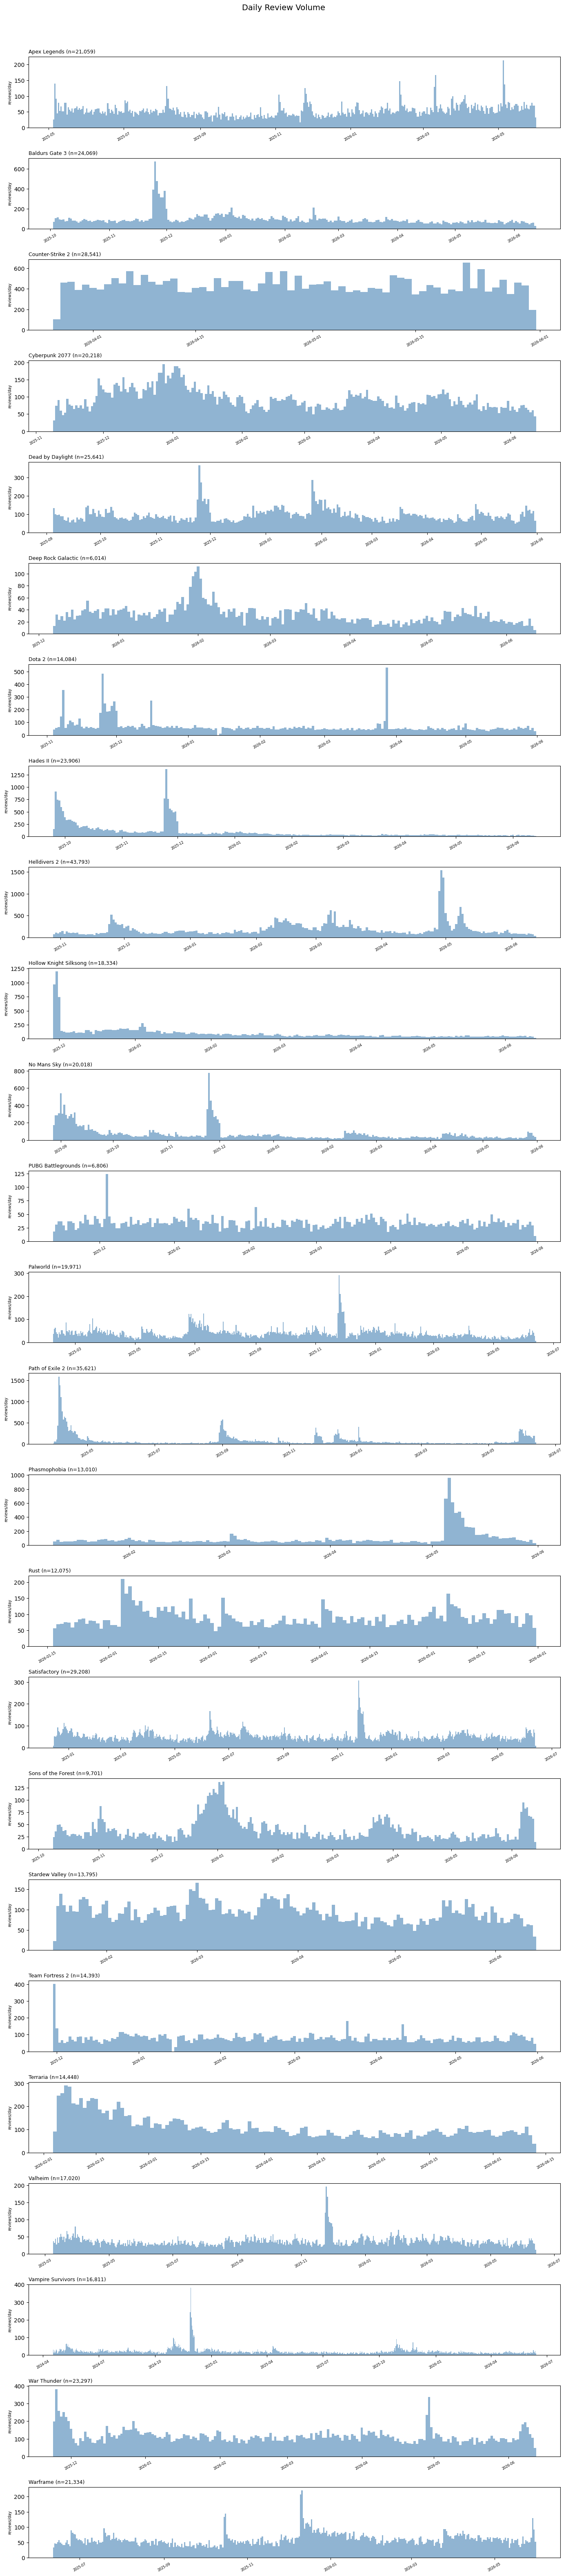

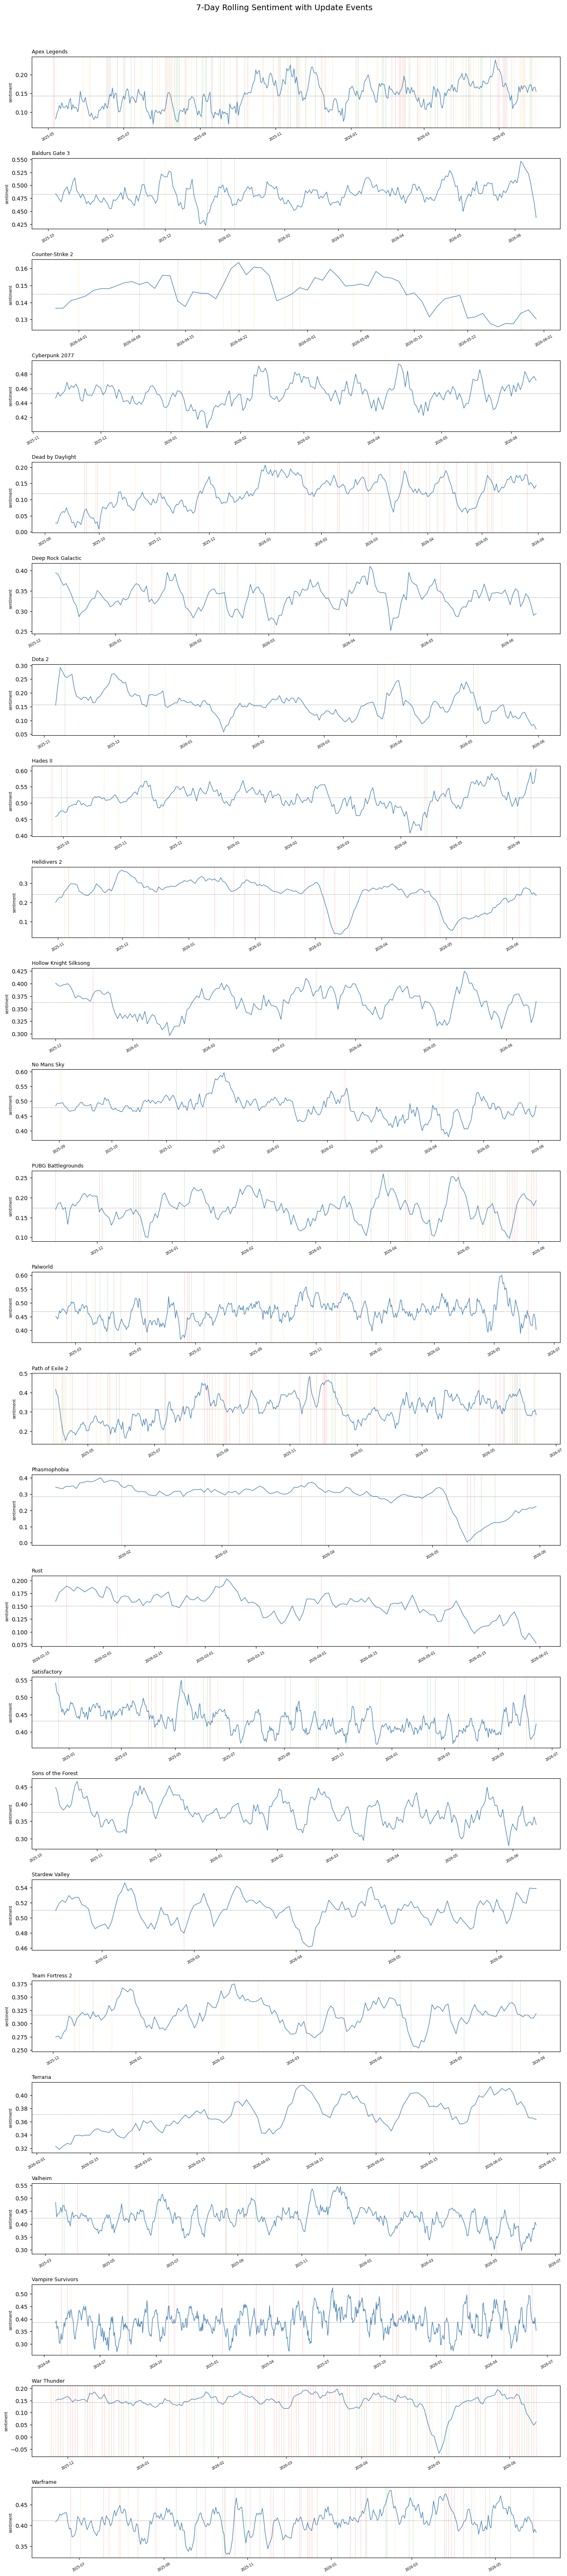

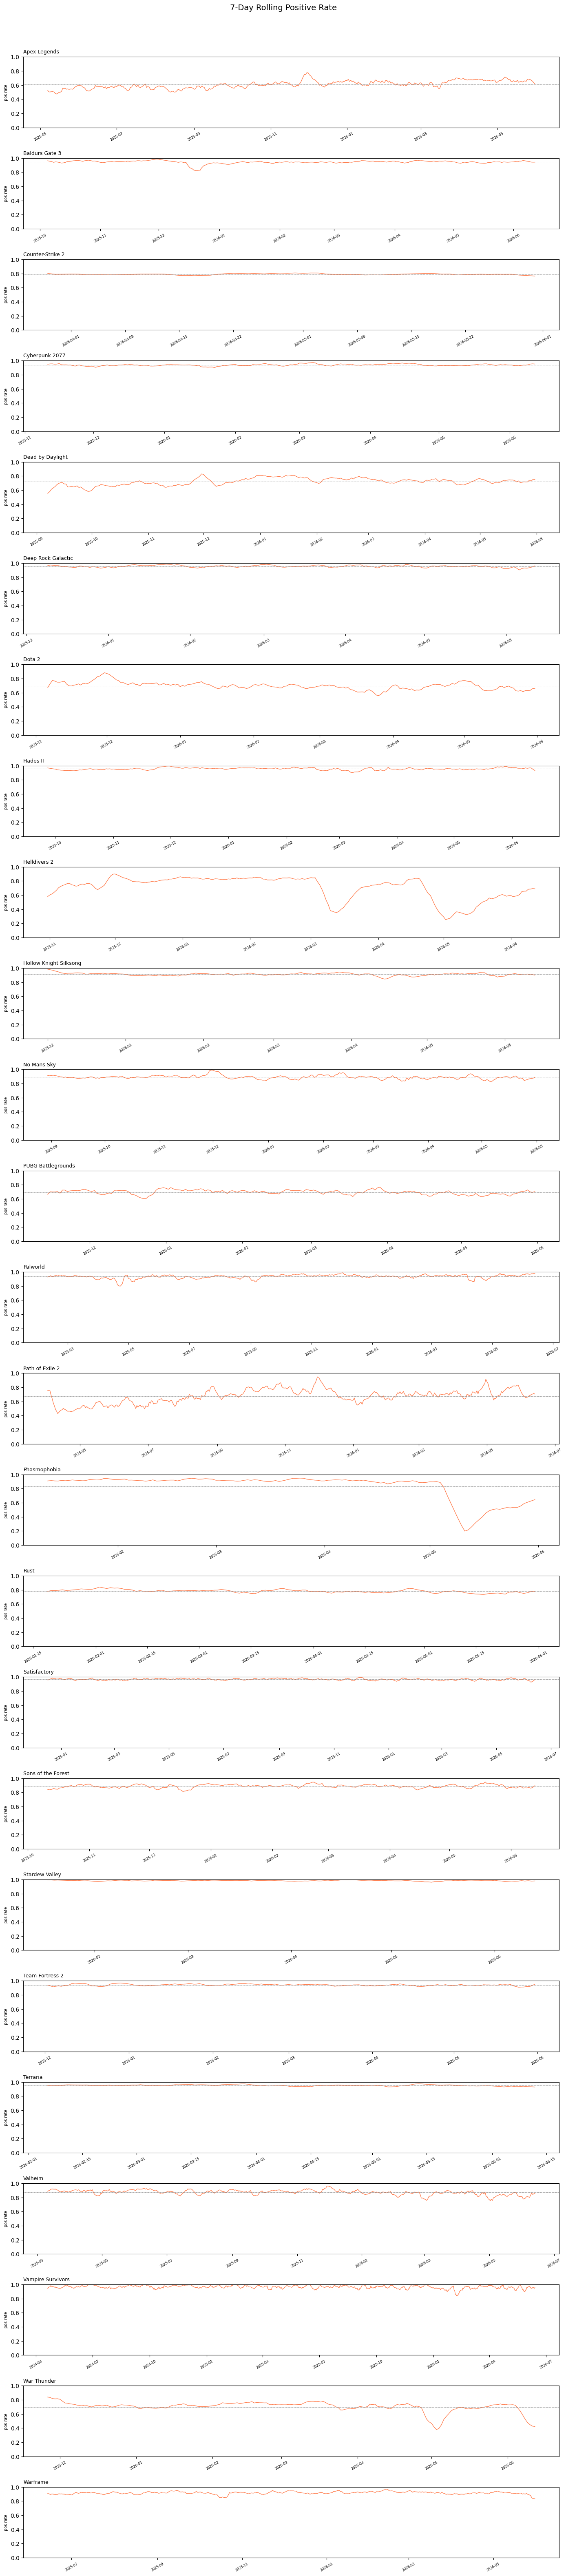

All figures saved.


In [12]:
# Cell 12: EDA figures — daily volume, rolling sentiment + events, rolling positive rate

import matplotlib.pyplot as plt

daily = pd.read_csv(f'{OUT}/daily_metrics.csv')
events = pd.read_csv(f'{OUT}/update_events.csv')
daily['date'] = pd.to_datetime(daily['date_str'])
events['date'] = pd.to_datetime(events['date_str'])

games = sorted(daily['game'].unique())
n = len(games)

# Plot 1: daily review volume
fig, axes = plt.subplots(n, 1, figsize=(14, 2.5 * n))
fig.suptitle('Daily Review Volume', fontsize=14, y=1.01)
for i, game in enumerate(games):
    ax = axes[i]
    g = daily[daily['game'] == game]
    ax.bar(g['date'], g['review_count'], width=1, color='steelblue', alpha=0.6)
    ax.set_title(f'{game} (n={g["review_count"].sum():,.0f})', fontsize=9, loc='left')
    ax.set_ylabel('reviews/day', fontsize=7)
    ax.tick_params(axis='x', rotation=30, labelsize=6)
plt.tight_layout()
plt.savefig(f'{OUT}/fig_daily_volume.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2: sentiment + event markers
fig, axes = plt.subplots(n, 1, figsize=(14, 2.5 * n))
fig.suptitle('7-Day Rolling Sentiment with Update Events', fontsize=14, y=1.01)
type_colors = {'major_content': 'red', 'balance': 'orange', 'maintenance': 'green'}
for i, game in enumerate(games):
    ax = axes[i]
    g = daily[daily['game'] == game]
    e = events[events['game'] == game]
    ax.plot(g['date'], g['sentiment_7d'], color='steelblue', linewidth=1)
    ax.axhline(y=g['sentiment_mean'].mean(), color='gray', linestyle='--', linewidth=0.5)
    for _, ev in e.iterrows():
        if g['date'].min() <= ev['date'] <= g['date'].max():
            ax.axvline(x=ev['date'], color=type_colors.get(ev['update_type'], 'gray'),
                      alpha=0.3, linewidth=0.5)
    ax.set_title(game, fontsize=9, loc='left')
    ax.set_ylabel('sentiment', fontsize=7)
    ax.tick_params(axis='x', rotation=30, labelsize=6)
plt.tight_layout()
plt.savefig(f'{OUT}/fig_sentiment_events.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 3: positive rate
fig, axes = plt.subplots(n, 1, figsize=(14, 2.5 * n))
fig.suptitle('7-Day Rolling Positive Rate', fontsize=14, y=1.01)
for i, game in enumerate(games):
    ax = axes[i]
    g = daily[daily['game'] == game]
    ax.plot(g['date'], g['pos_rate_7d'], color='coral', linewidth=1)
    ax.axhline(y=g['pos_rate'].mean(), color='gray', linestyle='--', linewidth=0.5)
    ax.set_title(game, fontsize=9, loc='left')
    ax.set_ylabel('pos rate', fontsize=7)
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=30, labelsize=6)
plt.tight_layout()
plt.savefig(f'{OUT}/fig_positive_rate.png', dpi=150, bbox_inches='tight')
plt.show()

print('All figures saved.')

In [13]:
# Cell 13: Final data inventory — saved files and dataset size

print('=' * 60)
print(f'DATA INVENTORY ({daily["game"].nunique()} games)')
print('=' * 60)
total = 0
for f in sorted(os.listdir(OUT)):
    if f.endswith(('.csv', '.png')):
        size = os.path.getsize(f'{OUT}/{f}') / (1024*1024)
        total += size
        print(f'  {f:<35} {size:>7.1f} MB')
print(f'  {"TOTAL":<35} {total:>7.1f} MB')
print(f'\nGames in dataset: {daily["game"].nunique()}')

print('\nFiles used by the event-study section below:')
print('  reviews_clean.csv      -> all reviews with cleaned text')
print('  reviews_sentiment.csv  -> English reviews with sentiment scores')
print('  update_events.csv      -> classified update events (independent var)')
print('  daily_metrics.csv      -> daily review count + sentiment (dependent var)')
print('  ccu_raw.csv            -> monthly CCU (supplementary)')

DATA INVENTORY (25 games)
  analysis_games.csv                      0.0 MB
  car_results.csv                         0.1 MB
  ccu_raw.csv                             1.0 MB
  daily_ar.csv                            0.2 MB
  daily_metrics.csv                       1.0 MB
  fig_daily_volume.png                    0.6 MB
  fig_event_window.png                    0.2 MB
  fig_placebo.png                         0.1 MB
  fig_positive_rate.png                   0.9 MB
  fig_regression_coefs.png                0.0 MB
  fig_sentiment_events.png                1.9 MB
  news_raw.csv                           24.8 MB
  placebo_results.csv                     0.0 MB
  quality_screening.csv                   0.0 MB
  reviews_1030300.csv                    20.6 MB
  reviews_105600.csv                     10.7 MB
  reviews_1086940.csv                    18.6 MB
  reviews_1091500.csv                    19.7 MB
  reviews_1145350.csv                    16.9 MB
  reviews_1172470.csv                    17

In [14]:
# Cell 14: Load daily metrics + events, restrict to the pre-registered analysis sample

import warnings
from scipy import stats
warnings.filterwarnings('ignore')

daily = pd.read_csv(f'{OUT}/daily_metrics.csv')
events = pd.read_csv(f'{OUT}/update_events.csv')
daily['date'] = pd.to_datetime(daily['date_str'])
events['date'] = pd.to_datetime(events['date_str'])

print(f'Daily metrics: {len(daily):,} rows, {daily["game"].nunique()} games')
print(f'Update events: {len(events):,} events')
print(events['update_type'].value_counts())

# Restrict to the pre-registered analysis sample (from quality screening)
analysis_games = pd.read_csv(f'{OUT}/analysis_games.csv')['game'].tolist()
daily = daily[daily['game'].isin(analysis_games)].copy()
events = events[events['game'].isin(analysis_games)].copy()
print(f'\nRestricted to {len(analysis_games)} games passing quality screening:')
print(', '.join(analysis_games))
print(f'After restriction — daily: {len(daily):,} rows, events: {len(events):,}')

Daily metrics: 7,023 rows, 25 games
Update events: 3,332 events
update_type
maintenance      1338
major_content    1295
balance           699
Name: count, dtype: int64

Restricted to 15 games passing quality screening:
Helldivers 2, Dead by Daylight, Rust, Hollow Knight Silksong, Stardew Valley, Cyberpunk 2077, Baldurs Gate 3, Team Fortress 2, Phasmophobia, Hades II, Dota 2, Path of Exile 2, No Mans Sky, Apex Legends, Warframe
After restriction — daily: 3,703 rows, events: 1,728


In [15]:
# Cell 15: Tag clean events (>3-day gap) and drop seasonal updates

events_clean = events.sort_values(['game', 'date']).copy()
events_clean['days_since_last'] = events_clean.groupby('game')['date'].diff().dt.days
events_clean['days_since_last'] = events_clean['days_since_last'].fillna(999)
events_clean['is_clean'] = events_clean['days_since_last'] > 3

events_main = events_clean[events_clean['update_type'] != 'seasonal'].copy()

print(f'Total events: {len(events_clean)}')
print(f'After excluding seasonal: {len(events_main)}')
print(f'Clean events (3-day threshold): {events_main["is_clean"].sum()} ({events_main["is_clean"].mean()*100:.0f}%)')
print(f'\nBy type:')
print(events_main.groupby('update_type')[['is_clean']].agg(['count', 'mean']).round(2))
print(f'\nBy game:')
print(events_main.groupby('game')[['is_clean']].agg(['count', 'mean']).round(2))

Total events: 1728
After excluding seasonal: 1728
Clean events (3-day threshold): 1210 (70%)

By type:
              is_clean      
                 count  mean
update_type                 
balance            360  0.66
maintenance        585  0.65
major_content      783  0.75

By game:
                       is_clean      
                          count  mean
game                                 
Apex Legends                223  0.52
Baldurs Gate 3               29  1.00
Cyberpunk 2077               31  0.77
Dead by Daylight            188  0.68
Dota 2                      232  0.58
Hades II                     31  0.90
Helldivers 2                 93  0.78
Hollow Knight Silksong        6  1.00
No Mans Sky                 100  0.92
Path of Exile 2              92  0.50
Phasmophobia                165  0.73
Rust                        234  0.88
Stardew Valley               47  0.81
Team Fortress 2              98  0.64
Warframe                    159  0.67


In [16]:
# Cell 16: Build per-game day-of-week baselines (expected reviews / positive rate)

baseline = daily.groupby(['game', 'day_of_week']).agg(
    expected_reviews=('review_count', 'mean'),
    expected_pos_rate=('pos_rate', 'mean'),
).reset_index()

print('Baseline example (Counter-Strike 2):')
cs = baseline[baseline['game'] == 'Counter-Strike 2'].sort_values('day_of_week')
dow_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
cs['dow_name'] = cs['day_of_week'].map(lambda x: dow_names[x])
print(cs[['dow_name', 'expected_reviews', 'expected_pos_rate']].to_string(index=False))

Baseline example (Counter-Strike 2):
Empty DataFrame
Columns: [dow_name, expected_reviews, expected_pos_rate]
Index: []


In [17]:
# Cell 17: Compute CAR per event and standardize within each game (z-score)

def compute_car(events_df, daily_df, baseline_df, window=7):
    results = []
    for _, ev in events_df.iterrows():
        game = ev['game']
        t0 = ev['date']
        t_end = t0 + pd.Timedelta(days=window)

        mask = (daily_df['game'] == game) & (daily_df['date'] >= t0) & (daily_df['date'] <= t_end)
        window_data = daily_df[mask].copy()

        if len(window_data) < 4:
            continue

        bl = baseline_df[baseline_df['game'] == game]
        window_data = window_data.merge(bl, on=['game', 'day_of_week'], how='left')

        window_data['ar_reviews'] = window_data['review_count'] - window_data['expected_reviews']
        window_data['ar_pos_rate'] = window_data['pos_rate'] - window_data['expected_pos_rate']

        car_reviews = window_data['ar_reviews'].sum()
        car_pos_rate = window_data['ar_pos_rate'].mean()

        results.append({
            'game': game,
            'event_date': t0,
            'update_type': ev['update_type'],
            'word_count': ev['word_count'],
            'log_magnitude': ev['log_magnitude'],
            'days_since_last': ev['days_since_last'],
            'is_clean': ev['is_clean'],
            'car_reviews': car_reviews,
            'car_pos_rate': car_pos_rate,
            'window_days': len(window_data),
        })

    return pd.DataFrame(results)

def add_within_game_z(df, cols=('car_reviews', 'car_pos_rate')):
    """Standardize each CAR column within each game (z-score).
    Games differ in review volume by up to two orders of magnitude, so raw CAR
    is not comparable across games. The z-score expresses each event's CAR in
    units of that game's own standard deviation, removing scale dominance by
    high-volume titles."""
    for col in cols:
        df[col + '_z'] = df.groupby('game')[col].transform(
            lambda s: (s - s.mean()) / s.std(ddof=0) if s.std(ddof=0) > 0 else 0.0
        ).fillna(0.0)
    return df

# Compute CAR on the real events, then standardize within game
df_car = compute_car(events_main, daily, baseline)
df_car = add_within_game_z(df_car)

print(f'Events with valid CAR: {len(df_car)}')
print(f'  of which clean: {df_car["is_clean"].sum()}')
print(f'\nStandardized CAR (z) summary by update type (all events):')
print(df_car.groupby('update_type')[['car_reviews_z', 'car_pos_rate_z']].agg(['mean', 'median', 'count']).round(3))
print(f'\nRaw CAR summary by update type (for reference):')
print(df_car.groupby('update_type')[['car_reviews', 'car_pos_rate']].agg(['mean', 'median', 'count']).round(3))
print(f'\nStandardized CAR (z) — clean events only:')
print(df_car[df_car['is_clean']].groupby('update_type')[['car_reviews_z', 'car_pos_rate_z']].agg(['mean', 'median', 'count']).round(3))

Events with valid CAR: 398
  of which clean: 229

Standardized CAR (z) summary by update type (all events):
              car_reviews_z              car_pos_rate_z             
                       mean median count           mean median count
update_type                                                         
balance              -0.009 -0.283   107         -0.011 -0.013   107
maintenance          -0.193 -0.400   131         -0.061  0.021   131
major_content         0.164 -0.038   160          0.057  0.211   160

Raw CAR summary by update type (for reference):
              car_reviews               car_pos_rate             
                     mean  median count         mean median count
update_type                                                      
balance           319.810  -5.750   107       -0.011  0.000   107
maintenance       120.306   3.448   131       -0.015 -0.000   131
major_content     166.771  47.527   160        0.001  0.007   160

Standardized CAR (z) — clean eve

In [18]:
# Cell 18: Significance tests — each type's CAR vs 0, and pairwise type differences
# Uses within-game standardized CAR (z) to avoid scale dominance by high-volume games.

test_types = ['major_content', 'balance', 'maintenance']

print('=' * 70)
print('TEST 1: Is each update type\'s standardized CAR significantly different from zero?')
print('=' * 70)

for label, subset in [('ALL EVENTS', df_car), ('CLEAN EVENTS ONLY', df_car[df_car['is_clean']])]:
    print(f'\n>>> {label} <<<')
    for dv in ['car_reviews_z', 'car_pos_rate_z']:
        print(f'\n  --- DV: {dv} ---')
        for utype in test_types:
            vals = subset[subset['update_type'] == utype][dv].dropna()
            if len(vals) < 5:
                print(f'    {utype:<18} n={len(vals):>4}  SKIPPED (n<5)')
                continue

            t_stat, t_p = stats.ttest_1samp(vals, 0)
            try:
                w_stat, w_p = stats.wilcoxon(vals, alternative='two-sided')
            except:
                w_p = np.nan

            sig_t = '***' if t_p < 0.01 else '**' if t_p < 0.05 else '*' if t_p < 0.1 else ''

            print(f'    {utype:<18} n={len(vals):>4}  '
                  f'mean={vals.mean():>8.3f}  median={vals.median():>8.3f}  '
                  f't={t_stat:>6.2f} p={t_p:.4f}{sig_t}  W_p={w_p:.4f}')

print(f'\n{"=" * 70}')
print('TEST 2: Pairwise comparison between update types')
print('=' * 70)

pairs = [
    ('major_content', 'maintenance'),
    ('major_content', 'balance'),
    ('balance', 'maintenance'),
]

for label, subset in [('ALL EVENTS', df_car), ('CLEAN EVENTS ONLY', df_car[df_car['is_clean']])]:
    print(f'\n>>> {label} <<<')
    for dv in ['car_reviews_z', 'car_pos_rate_z']:
        print(f'\n  --- DV: {dv} ---')
        for a, b in pairs:
            va = subset[subset['update_type'] == a][dv].dropna()
            vb = subset[subset['update_type'] == b][dv].dropna()
            if len(va) < 5 or len(vb) < 5:
                print(f'    {a} vs {b}  SKIPPED (insufficient n)')
                continue

            t_stat, t_p = stats.ttest_ind(va, vb)
            u_stat, u_p = stats.mannwhitneyu(va, vb, alternative='two-sided')

            print(f'    {a} vs {b}')
            print(f'      means: {va.mean():.3f} vs {vb.mean():.3f}  diff={va.mean()-vb.mean():.3f}')
            print(f'      t-test: p={t_p:.4f}  Mann-Whitney: p={u_p:.4f}')

TEST 1: Is each update type's standardized CAR significantly different from zero?

>>> ALL EVENTS <<<

  --- DV: car_reviews_z ---
    major_content      n= 160  mean=   0.164  median=  -0.038  t=  1.91 p=0.0579*  W_p=0.7426
    balance            n= 107  mean=  -0.009  median=  -0.283  t= -0.09 p=0.9295  W_p=0.2632
    maintenance        n= 131  mean=  -0.193  median=  -0.400  t= -2.66 p=0.0087***  W_p=0.0012

  --- DV: car_pos_rate_z ---
    major_content      n= 160  mean=   0.057  median=   0.211  t=  0.70 p=0.4860  W_p=0.1953
    balance            n= 107  mean=  -0.011  median=  -0.013  t= -0.11 p=0.9097  W_p=0.9480
    maintenance        n= 131  mean=  -0.061  median=   0.021  t= -0.71 p=0.4796  W_p=0.5704

>>> CLEAN EVENTS ONLY <<<

  --- DV: car_reviews_z ---
    major_content      n= 100  mean=   0.169  median=  -0.091  t=  1.54 p=0.1261  W_p=0.8097
    balance            n=  59  mean=  -0.242  median=  -0.443  t= -2.15 p=0.0358**  W_p=0.0017
    maintenance        n=  70  me

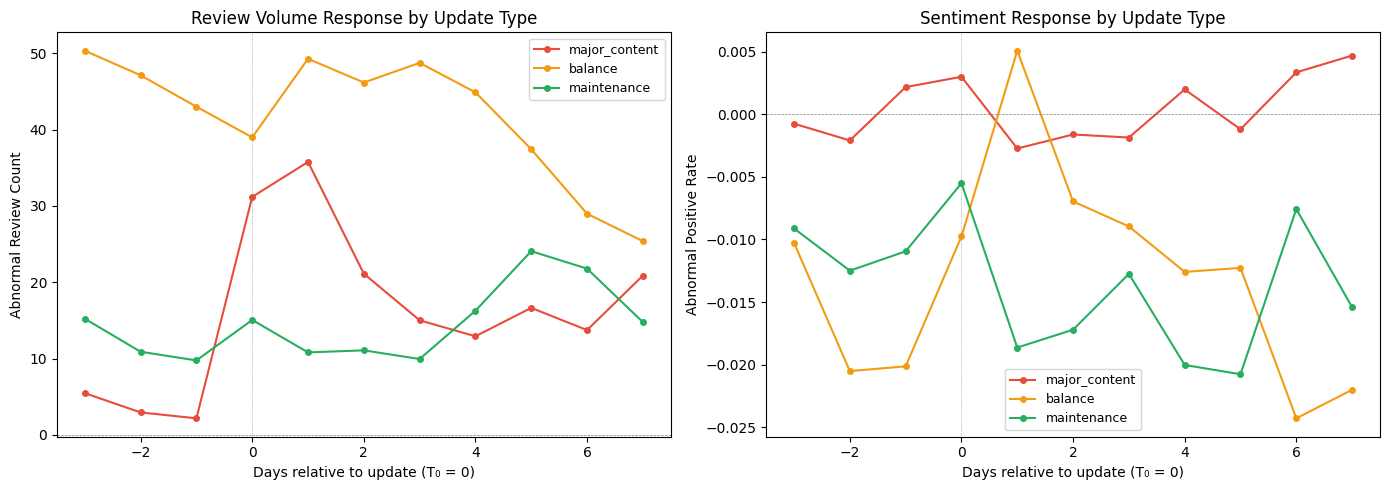

Saved: fig_event_window.png


In [19]:
# Cell 19: Event-window plot — mean abnormal response by day around the update (core paper figure)

def compute_daily_ar(events_df, daily_df, baseline_df, pre=3, post=7):
    rows = []
    for _, ev in events_df.iterrows():
        game = ev['game']
        t0 = ev['date']
        bl = baseline_df[baseline_df['game'] == game]

        for d in range(-pre, post + 1):
            day = t0 + pd.Timedelta(days=d)
            row = daily_df[(daily_df['game'] == game) & (daily_df['date'] == day)]
            if row.empty:
                continue
            row = row.iloc[0]
            exp = bl[bl['day_of_week'] == row['day_of_week']]
            if exp.empty:
                continue
            exp = exp.iloc[0]
            rows.append({
                'event_day': d,
                'update_type': ev['update_type'],
                'ar_reviews': row['review_count'] - exp['expected_reviews'],
                'ar_pos_rate': row['pos_rate'] - exp['expected_pos_rate'],
            })
    return pd.DataFrame(rows)

df_daily_ar = compute_daily_ar(events_main, daily, baseline)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = {'major_content': '#e74c3c', 'balance': '#f39c12', 'maintenance': '#27ae60'}

for utype, color in colors.items():
    sub = df_daily_ar[df_daily_ar['update_type'] == utype]
    avg = sub.groupby('event_day')['ar_reviews'].mean()
    ax1.plot(avg.index, avg.values, marker='o', markersize=4,
             color=color, label=utype, linewidth=1.5)

ax1.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
ax1.axvline(x=0, color='gray', linestyle=':', linewidth=0.5)
ax1.set_xlabel('Days relative to update (T₀ = 0)')
ax1.set_ylabel('Abnormal Review Count')
ax1.set_title('Review Volume Response by Update Type')
ax1.legend(fontsize=9)

for utype, color in colors.items():
    sub = df_daily_ar[df_daily_ar['update_type'] == utype]
    avg = sub.groupby('event_day')['ar_pos_rate'].mean()
    ax2.plot(avg.index, avg.values, marker='o', markersize=4,
             color=color, label=utype, linewidth=1.5)

ax2.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
ax2.axvline(x=0, color='gray', linestyle=':', linewidth=0.5)
ax2.set_xlabel('Days relative to update (T₀ = 0)')
ax2.set_ylabel('Abnormal Positive Rate')
ax2.set_title('Sentiment Response by Update Type')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUT}/fig_event_window.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_event_window.png')

In [20]:
# Cell 20: CAR breakdown by game × update type

pivot_reviews = df_car.groupby(['game', 'update_type'])['car_reviews'].agg(['mean', 'count'])
pivot_reviews.columns = ['mean_car', 'n_events']
pivot_reviews = pivot_reviews.round(2)

print('CAR (Review Count) by Game × Update Type:')
print(pivot_reviews.unstack(fill_value='-'))

pivot_pos = df_car.groupby(['game', 'update_type'])['car_pos_rate'].agg(['mean', 'count'])
pivot_pos.columns = ['mean_car', 'n_events']
pivot_pos = pivot_pos.round(4)

print('\nCAR (Positive Rate) by Game × Update Type:')
print(pivot_pos.unstack(fill_value='-'))

CAR (Review Count) by Game × Update Type:
                       mean_car                           n_events  \
update_type             balance maintenance major_content  balance   
game                                                                 
Apex Legends               2.57        2.74         63.68       45   
Baldurs Gate 3            -30.4      462.32             -        1   
Cyberpunk 2077                -      377.56             -        -   
Dead by Daylight         -70.02      -85.88         87.36       11   
Dota 2                   -16.82       56.68             -        5   
Hades II                1201.34      375.16        895.48        4   
Helldivers 2            -479.97     -182.99        353.06        3   
Hollow Knight Silksong        -     -238.75        499.03        -   
No Mans Sky              911.21     -102.95       1098.93        2   
Path of Exile 2         1230.64      652.23          25.5       24   
Phasmophobia                  -       90.53     

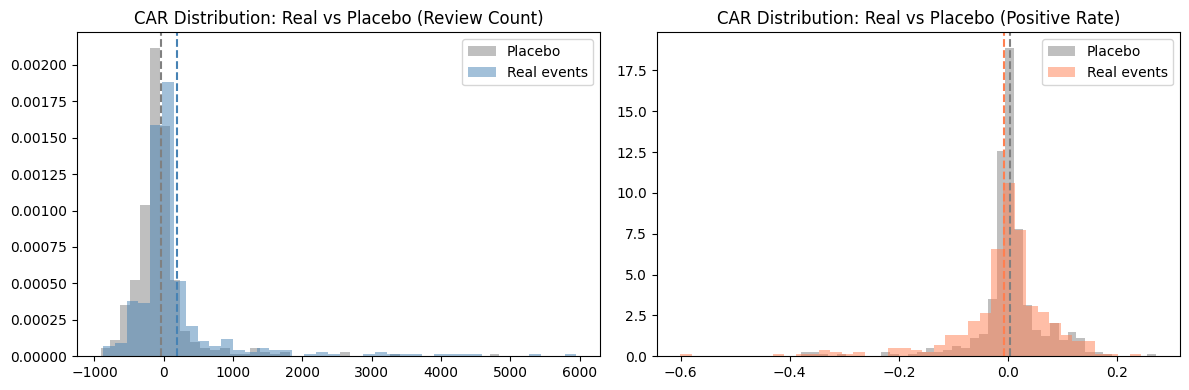

Real vs Placebo (reviews): mean 192.62 vs -44.29, p=0.0000
Real vs Placebo (pos rate): mean -0.0075 vs 0.0029, p=0.0497


In [21]:
# Cell 21: Placebo test — real events vs random non-update dates

np.random.seed(42)

def placebo_test(daily_df, events_df, baseline_df, n_placebo=500):
    placebo_events = []
    for game in events_df['game'].unique():
        g_daily = daily_df[daily_df['game'] == game]
        g_events = events_df[events_df['game'] == game]
        event_dates = set(g_events['date'].dt.strftime('%Y-%m-%d'))

        candidates = g_daily[~g_daily['date_str'].isin(event_dates)]
        if len(candidates) < 20:
            continue

        n = min(n_placebo // events_df['game'].nunique(), len(candidates))
        sampled = candidates.sample(n, random_state=42)

        for _, row in sampled.iterrows():
            placebo_events.append({
                'game': game,
                'date': row['date'],
                'update_type': 'placebo',
                'word_count': 0,
                'log_magnitude': 0,
                'days_since_last': 999,
                'is_clean': True,
            })

    return compute_car(pd.DataFrame(placebo_events), daily_df, baseline_df)

df_placebo = placebo_test(daily, events_main, baseline)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

real_reviews = df_car['car_reviews'].dropna()
placebo_reviews = df_placebo['car_reviews'].dropna()

ax1.hist(placebo_reviews, bins=40, alpha=0.5, color='gray', label='Placebo', density=True)
ax1.hist(real_reviews, bins=40, alpha=0.5, color='steelblue', label='Real events', density=True)
ax1.axvline(x=real_reviews.mean(), color='steelblue', linestyle='--')
ax1.axvline(x=placebo_reviews.mean(), color='gray', linestyle='--')
ax1.set_title('CAR Distribution: Real vs Placebo (Review Count)')
ax1.legend()

real_pos = df_car['car_pos_rate'].dropna()
placebo_pos = df_placebo['car_pos_rate'].dropna()

ax2.hist(placebo_pos, bins=40, alpha=0.5, color='gray', label='Placebo', density=True)
ax2.hist(real_pos, bins=40, alpha=0.5, color='coral', label='Real events', density=True)
ax2.axvline(x=real_pos.mean(), color='coral', linestyle='--')
ax2.axvline(x=placebo_pos.mean(), color='gray', linestyle='--')
ax2.set_title('CAR Distribution: Real vs Placebo (Positive Rate)')
ax2.legend()

plt.tight_layout()
plt.savefig(f'{OUT}/fig_placebo.png', dpi=150, bbox_inches='tight')
plt.show()

t_rev, p_rev = stats.ttest_ind(real_reviews, placebo_reviews)
t_pos, p_pos = stats.ttest_ind(real_pos, placebo_pos)
print(f'Real vs Placebo (reviews): mean {real_reviews.mean():.2f} vs {placebo_reviews.mean():.2f}, p={p_rev:.4f}')
print(f'Real vs Placebo (pos rate): mean {real_pos.mean():.4f} vs {placebo_pos.mean():.4f}, p={p_pos:.4f}')

In [22]:
# Cell 22: Save event-study results (CAR, daily AR, placebo) to CSV

df_car.to_csv(f'{OUT}/car_results.csv', index=False)
df_daily_ar.to_csv(f'{OUT}/daily_ar.csv', index=False)
df_placebo.to_csv(f'{OUT}/placebo_results.csv', index=False)

print('Saved:')
print('  car_results.csv     -> CAR per event (input for regression)')
print('  daily_ar.csv        -> day-by-day AR (for event window plots)')
print('  placebo_results.csv -> placebo test results')

Saved:
  car_results.csv     -> CAR per event (input for regression)
  daily_ar.csv        -> day-by-day AR (for event window plots)
  placebo_results.csv -> placebo test results


In [23]:
# Cell 23: Prepare regression variables (type dummies, event day-of-week)

!pip install statsmodels -q
import statsmodels.api as sm
import statsmodels.formula.api as smf

df_reg = df_car.copy()
df_reg['event_dow'] = pd.to_datetime(df_reg['event_date']).dt.dayofweek
df_reg['is_major'] = (df_reg['update_type'] == 'major_content').astype(int)
df_reg['is_balance'] = (df_reg['update_type'] == 'balance').astype(int)

print(f'Regression sample: {len(df_reg)} events')
print(df_reg['update_type'].value_counts())

Regression sample: 398 events
update_type
major_content    160
maintenance      131
balance          107
Name: count, dtype: int64


In [24]:
# Cell 24: OLS on standardized CAR (review count) — four progressive models
# DV is within-game z-scored CAR, so coefficients are in units of each game's SD.

from statsmodels.iolib.summary2 import summary_col

m1 = smf.ols('car_reviews_z ~ is_major + is_balance', data=df_reg).fit()
m2 = smf.ols('car_reviews_z ~ is_major + is_balance + log_magnitude', data=df_reg).fit()
m3 = smf.ols('car_reviews_z ~ is_major + is_balance + log_magnitude + days_since_last + C(event_dow)', data=df_reg).fit()
m4 = smf.ols('car_reviews_z ~ is_major + is_balance + log_magnitude + days_since_last + C(event_dow) + C(game)', data=df_reg).fit()

table = summary_col(
    [m1, m2, m3, m4],
    model_names=['(1) Type', '(2) +Magnitude', '(3) +Controls', '(4) +Game FE'],
    stars=True,
    info_dict={
        'N': lambda x: f'{int(x.nobs)}',
        'R²': lambda x: f'{x.rsquared:.3f}',
        'Adj R²': lambda x: f'{x.rsquared_adj:.3f}',
    },
    regressor_order=['is_major', 'is_balance', 'log_magnitude', 'days_since_last'],
)

print('=' * 70)
print('TABLE: OLS Regression — Standardized CAR (Review Count)')
print('Reference category: maintenance')
print('=' * 70)
print(table)

TABLE: OLS Regression — Standardized CAR (Review Count)
Reference category: maintenance

                                   (1) Type (2) +Magnitude (3) +Controls (4) +Game FE
-------------------------------------------------------------------------------------
is_major                          0.3577*** 0.1475         0.1621        0.1999      
                                  (0.1167)  (0.1294)       (0.1310)      (0.1376)    
is_balance                        0.1847    0.0348         0.0313        0.0082      
                                  (0.1291)  (0.1341)       (0.1349)      (0.1386)    
log_magnitude                               0.1479***      0.1475***     0.1807***   
                                            (0.0417)       (0.0422)      (0.0450)    
days_since_last                                            -0.0023       -0.0119**   
                                                           (0.0020)      (0.0047)    
Intercept                         -0.1935** -0.8791

In [25]:
# Cell 25: OLS on standardized CAR (positive rate) — same four models

m1p = smf.ols('car_pos_rate_z ~ is_major + is_balance', data=df_reg).fit()
m2p = smf.ols('car_pos_rate_z ~ is_major + is_balance + log_magnitude', data=df_reg).fit()
m3p = smf.ols('car_pos_rate_z ~ is_major + is_balance + log_magnitude + days_since_last + C(event_dow)', data=df_reg).fit()
m4p = smf.ols('car_pos_rate_z ~ is_major + is_balance + log_magnitude + days_since_last + C(event_dow) + C(game)', data=df_reg).fit()

table_p = summary_col(
    [m1p, m2p, m3p, m4p],
    model_names=['(1) Type', '(2) +Magnitude', '(3) +Controls', '(4) +Game FE'],
    stars=True,
    info_dict={
        'N': lambda x: f'{int(x.nobs)}',
        'R²': lambda x: f'{x.rsquared:.3f}',
        'Adj R²': lambda x: f'{x.rsquared_adj:.3f}',
    },
    regressor_order=['is_major', 'is_balance', 'log_magnitude', 'days_since_last'],
)

print('=' * 70)
print('TABLE: OLS Regression — Standardized CAR (Positive Rate)')
print('Reference category: maintenance')
print('=' * 70)
print(table_p)

TABLE: OLS Regression — Standardized CAR (Positive Rate)
Reference category: maintenance

                                  (1) Type (2) +Magnitude (3) +Controls (4) +Game FE
------------------------------------------------------------------------------------
is_major                          0.1185   0.1902         0.1836        0.1860      
                                  (0.1180) (0.1326)       (0.1343)      (0.1425)    
is_balance                        0.0507   0.1019         0.1154        0.1262      
                                  (0.1305) (0.1374)       (0.1383)      (0.1435)    
log_magnitude                              -0.0505        -0.0526       -0.0582     
                                           (0.0427)       (0.0432)      (0.0466)    
days_since_last                                           0.0012        0.0071      
                                                          (0.0020)      (0.0048)    
Intercept                         -0.0612  0.1729         0.

In [26]:
# Cell 26: Robustness checks on the main model (standardized CAR)

print('=' * 70)
print('ROBUSTNESS CHECKS (standardized CAR)')
print('=' * 70)

base_formula = ('car_reviews_z ~ is_major + is_balance + log_magnitude '
                '+ days_since_last + C(event_dow) + C(game)')

# (1) Leave-one-out: drop each game in turn, refit
print('\n[1] Leave-one-out (drop each game, refit, report is_major):')
loo = []
for g in sorted(df_reg['game'].unique()):
    sub = df_reg[df_reg['game'] != g]
    if sub['is_major'].sum() < 5:
        continue
    m = smf.ols(base_formula, data=sub).fit()
    loo.append((g, m.params['is_major'], m.pvalues['is_major']))
loo_df = pd.DataFrame(loo, columns=['dropped_game', 'is_major_coef', 'p_value'])
loo_df = loo_df.sort_values('p_value')
print(loo_df.round(4).to_string(index=False))
print(f"\n  Max p-value across all leave-one-out fits: {loo_df['p_value'].max():.4f}")
print(f"  -> is_major stays significant (p<0.05) dropping any single game: "
      f"{(loo_df['p_value'] < 0.05).all()}")

# (2) Clean events only (>3 days gap)
df_clean = df_reg[df_reg['is_clean']]
r2 = smf.ols(base_formula, data=df_clean).fit()
print('\n[2] Clean events only (>3 days gap):')
print(f"    is_major: coef={r2.params['is_major']:.3f}, p={r2.pvalues['is_major']:.4f}")
print(f"    N={int(r2.nobs)}, R²={r2.rsquared:.3f}")

# (3) Shorter window T0 to T+3 (recompute CAR and re-standardize)
df_car_short = compute_car(events_main, daily, baseline, window=3)
df_car_short = add_within_game_z(df_car_short)
df_short = df_car_short.copy()
df_short['event_dow'] = pd.to_datetime(df_short['event_date']).dt.dayofweek
df_short['is_major'] = (df_short['update_type'] == 'major_content').astype(int)
df_short['is_balance'] = (df_short['update_type'] == 'balance').astype(int)
r3 = smf.ols(base_formula, data=df_short).fit()
print('\n[3] Shorter window (T0 to T+3):')
print(f"    is_major: coef={r3.params['is_major']:.3f}, p={r3.pvalues['is_major']:.4f}")
print(f"    N={int(r3.nobs)}, R²={r3.rsquared:.3f}")

# (4) Drop the single highest-CAR game
top_game = df_reg.groupby('game')['car_reviews_z'].mean().idxmax()
df_drop_top = df_reg[df_reg['game'] != top_game]
r4 = smf.ols(base_formula, data=df_drop_top).fit()
print(f'\n[4] Drop highest-CAR game ({top_game}):')
print(f"    is_major: coef={r4.params['is_major']:.3f}, p={r4.pvalues['is_major']:.4f}")
print(f"    N={int(r4.nobs)}, R²={r4.rsquared:.3f}")

print('\n' + '=' * 70)
print('ROBUSTNESS SUMMARY — is_major coefficient (standardized)')
print('=' * 70)
print(f"  Main model (all events):  coef={m4.params['is_major']:.3f}  p={m4.pvalues['is_major']:.4f}")
print(f"  [2] Clean events:         coef={r2.params['is_major']:.3f}  p={r2.pvalues['is_major']:.4f}")
print(f"  [3] Short window (T+3):   coef={r3.params['is_major']:.3f}  p={r3.pvalues['is_major']:.4f}")
print(f"  [4] Drop top game:        coef={r4.params['is_major']:.3f}  p={r4.pvalues['is_major']:.4f}")
print(f"  [1] Leave-one-out max p:  {loo_df['p_value'].max():.4f}")

ROBUSTNESS CHECKS (standardized CAR)

[1] Leave-one-out (drop each game, refit, report is_major):
          dropped_game  is_major_coef  p_value
       Path of Exile 2         0.4261   0.0073
                Dota 2         0.2286   0.0978
        Baldurs Gate 3         0.2213   0.1072
                  Rust         0.2087   0.1318
        Stardew Valley         0.1999   0.1471
        Cyberpunk 2077         0.1997   0.1473
          Phasmophobia         0.2030   0.1487
              Hades II         0.1921   0.1684
          Apex Legends         0.2210   0.1758
Hollow Knight Silksong         0.1798   0.1956
          Helldivers 2         0.1772   0.2144
           No Mans Sky         0.1615   0.2487
      Dead by Daylight         0.1554   0.2853
       Team Fortress 2         0.1442   0.3023
              Warframe         0.1304   0.4013

  Max p-value across all leave-one-out fits: 0.4013
  -> is_major stays significant (p<0.05) dropping any single game: False

[2] Clean events only (

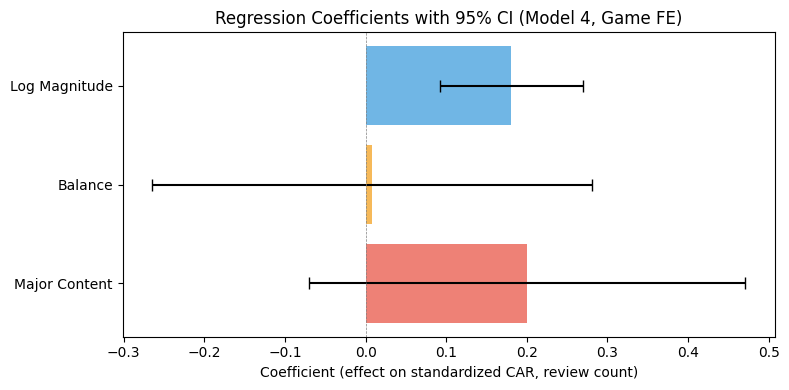

Saved: fig_regression_coefs.png


In [27]:
# Cell 27: Coefficient plot — Model 4 with 95% CI (standardized CAR)

coefs = {
    'Major Content': (m4.params['is_major'], m4.conf_int().loc['is_major']),
    'Balance': (m4.params['is_balance'], m4.conf_int().loc['is_balance']),
    'Log Magnitude': (m4.params['log_magnitude'], m4.conf_int().loc['log_magnitude']),
}

fig, ax = plt.subplots(figsize=(8, 4))
y_pos = range(len(coefs))
names = list(coefs.keys())
vals = [coefs[n][0] for n in names]
ci_low = [coefs[n][1][0] for n in names]
ci_high = [coefs[n][1][1] for n in names]
errors = [[v - l for v, l in zip(vals, ci_low)], [h - v for v, h in zip(vals, ci_high)]]

ax.barh(y_pos, vals, xerr=errors, color=['#e74c3c', '#f39c12', '#3498db'],
        alpha=0.7, capsize=4)
ax.set_yticks(y_pos)
ax.set_yticklabels(names)
ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.5)
ax.set_xlabel('Coefficient (effect on standardized CAR, review count)')
ax.set_title('Regression Coefficients with 95% CI (Model 4, Game FE)')

plt.tight_layout()
plt.savefig(f'{OUT}/fig_regression_coefs.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_regression_coefs.png')

In [28]:
# Cell 28: Save Model 4 regression summaries to text files

with open(f'{OUT}/regression_model4_summary.txt', 'w') as f:
    f.write(m4.summary().as_text())

with open(f'{OUT}/regression_model4p_summary.txt', 'w') as f:
    f.write(m4p.summary().as_text())

print('Saved: regression_model4_summary.txt, regression_model4p_summary.txt')
print('\nAll analysis complete. Ready for paper writing.')

Saved: regression_model4_summary.txt, regression_model4p_summary.txt

All analysis complete. Ready for paper writing.


In [29]:
# Cell 29: Robustness — three standardized DVs (reviews, positive rate, sentiment)

df_sent_daily = pd.read_csv(f'{OUT}/daily_metrics.csv')
df_sent_daily['date'] = pd.to_datetime(df_sent_daily['date_str'])

baseline_sent = df_sent_daily.groupby(['game', 'day_of_week']).agg(
    expected_sentiment=('sentiment_mean', 'mean'),
).reset_index()

def compute_car_sentiment(events_df, daily_df, baseline_df, window=7):
    results = []
    for _, ev in events_df.iterrows():
        game = ev['game']
        t0 = ev['date']
        t_end = t0 + pd.Timedelta(days=window)
        mask = (daily_df['game'] == game) & (daily_df['date'] >= t0) & (daily_df['date'] <= t_end)
        window_data = daily_df[mask].copy()
        if len(window_data) < 4:
            continue
        bl = baseline_df[baseline_df['game'] == game]
        window_data = window_data.merge(bl, on=['game', 'day_of_week'], how='left')
        window_data['ar_sentiment'] = window_data['sentiment_mean'] - window_data['expected_sentiment']
        results.append({
            'game': game,
            'event_date': t0,
            'update_type': ev['update_type'],
            'car_sentiment': window_data['ar_sentiment'].mean(),
        })
    return pd.DataFrame(results)

df_car_sent = compute_car_sentiment(events_main, df_sent_daily, baseline_sent)
df_car_sent['car_sentiment_z'] = df_car_sent.groupby('game')['car_sentiment'].transform(
    lambda s: (s - s.mean()) / s.std(ddof=0) if s.std(ddof=0) > 0 else 0.0
).fillna(0.0)

df_compare = df_car.merge(
    df_car_sent[['game', 'event_date', 'car_sentiment_z']],
    on=['game', 'event_date'], how='left'
)

print('=' * 70)
print('ROBUSTNESS: Three standardized DVs (mean CAR_z by update type)')
print('=' * 70)
for dv, label in [('car_reviews_z', 'Review Count'), ('car_pos_rate_z', 'Positive Rate'), ('car_sentiment_z', 'VADER Sentiment')]:
    print(f'\n--- {label} ---')
    for utype in ['major_content', 'balance', 'maintenance']:
        vals = df_compare[df_compare['update_type'] == utype][dv].dropna()
        if len(vals) < 5:
            continue
        t_stat, t_p = stats.ttest_1samp(vals, 0)
        sig = '***' if t_p < 0.01 else '**' if t_p < 0.05 else '*' if t_p < 0.1 else ''
        print(f'  {utype:<18} mean={vals.mean():>8.4f}  t={t_stat:>6.2f}  p={t_p:.4f}{sig}')

print(f'\n{"=" * 70}')
print('Major Content vs Maintenance — all three standardized DVs')
print('=' * 70)
for dv, label in [('car_reviews_z', 'Review Count'), ('car_pos_rate_z', 'Positive Rate'), ('car_sentiment_z', 'VADER Sentiment')]:
    va = df_compare[df_compare['update_type'] == 'major_content'][dv].dropna()
    vb = df_compare[df_compare['update_type'] == 'maintenance'][dv].dropna()
    t_stat, t_p = stats.ttest_ind(va, vb)
    print(f'  {label:<20} major={va.mean():.4f}  maint={vb.mean():.4f}  diff={va.mean()-vb.mean():.4f}  p={t_p:.4f}')

df_reg_sent = df_compare.copy()
df_reg_sent['event_dow'] = pd.to_datetime(df_reg_sent['event_date']).dt.dayofweek
df_reg_sent['is_major'] = (df_reg_sent['update_type'] == 'major_content').astype(int)
df_reg_sent['is_balance'] = (df_reg_sent['update_type'] == 'balance').astype(int)

m_sent = smf.ols('car_sentiment_z ~ is_major + is_balance + log_magnitude + days_since_last + C(event_dow) + C(game)',
                  data=df_reg_sent).fit()

print(f'\nRegression with standardized VADER Sentiment as DV (Model 4 spec):')
print(f'  is_major:   coef={m_sent.params["is_major"]:.4f}  p={m_sent.pvalues["is_major"]:.4f}')
print(f'  is_balance: coef={m_sent.params["is_balance"]:.4f}  p={m_sent.pvalues["is_balance"]:.4f}')
print(f'  R²={m_sent.rsquared:.3f}')

print(f'\n{"=" * 70}')
print('SUMMARY: Consistency across three standardized DVs')
print('=' * 70)
print(f'  Review Count:    is_major p={m4.pvalues["is_major"]:.4f}  ({"SIG" if m4.pvalues["is_major"] < 0.05 else "n.s."})')
print(f'  Positive Rate:   is_major p={m4p.pvalues["is_major"]:.4f}  ({"SIG" if m4p.pvalues["is_major"] < 0.05 else "n.s."})')
print(f'  VADER Sentiment: is_major p={m_sent.pvalues["is_major"]:.4f}  ({"SIG" if m_sent.pvalues["is_major"] < 0.05 else "n.s."})')

ROBUSTNESS: Three standardized DVs (mean CAR_z by update type)

--- Review Count ---
  major_content      mean=  0.1642  t=  1.91  p=0.0579*
  balance            mean= -0.0087  t= -0.09  p=0.9295
  maintenance        mean= -0.1935  t= -2.66  p=0.0087***

--- Positive Rate ---
  major_content      mean=  0.0572  t=  0.70  p=0.4860
  balance            mean= -0.0106  t= -0.11  p=0.9097
  maintenance        mean= -0.0612  t= -0.71  p=0.4796

--- VADER Sentiment ---
  major_content      mean=  0.0535  t=  0.67  p=0.5012
  balance            mean= -0.1075  t= -1.18  p=0.2388
  maintenance        mean=  0.0224  t=  0.25  p=0.8060

Major Content vs Maintenance — all three standardized DVs
  Review Count         major=0.1642  maint=-0.1935  diff=0.3577  p=0.0022
  Positive Rate        major=0.0572  maint=-0.0612  diff=0.1185  p=0.3229
  VADER Sentiment      major=0.0535  maint=0.0224  diff=0.0311  p=0.7964

Regression with standardized VADER Sentiment as DV (Model 4 spec):
  is_major:   coef=0

In [30]:
# Cell 30: Regression robustness — clustered SE, VIF, coefficient stability
# All on the standardized DV (car_reviews_z). Reference category: maintenance.

from statsmodels.stats.outliers_influence import variance_inflation_factor

# --- (A) Cluster-robust standard errors (clustered by game) ---
# Event-study standard practice: events within the same game are not independent.
m4_cluster = smf.ols(
    'car_reviews_z ~ is_major + is_balance + log_magnitude + days_since_last + C(event_dow) + C(game)',
    data=df_reg
).fit(cov_type='cluster', cov_kwds={'groups': df_reg['game']})

print('=' * 70)
print('(A) Model 4 with CLUSTER-ROBUST SE (clustered by game)')
print('=' * 70)
for v in ['is_major', 'is_balance', 'log_magnitude', 'days_since_last']:
    print(f'  {v:<16} coef={m4_cluster.params[v]:>7.3f}  SE={m4_cluster.bse[v]:>6.3f}  '
          f'p={m4_cluster.pvalues[v]:.4f}')
print(f'  N={int(m4_cluster.nobs)}  R²={m4_cluster.rsquared:.3f}')

# --- (B) VIF: is the is_major / log_magnitude collinearity actually severe? ---
vif_df = df_reg[['is_major', 'is_balance', 'log_magnitude', 'days_since_last']].copy()
vif_df = sm.add_constant(vif_df)
print('\n' + '=' * 70)
print('(B) Variance Inflation Factors (VIF < 5 = acceptable, < 10 = tolerable)')
print('=' * 70)
for i, col in enumerate(vif_df.columns):
    if col == 'const':
        continue
    vif = variance_inflation_factor(vif_df.values, i)
    print(f'  {col:<16} VIF={vif:.2f}')

# --- (C) Coefficient stability: is_major with and without log_magnitude ---
print('\n' + '=' * 70)
print('(C) is_major coefficient stability (does controlling for magnitude kill it?)')
print('=' * 70)
m_no_mag = smf.ols('car_reviews_z ~ is_major + is_balance + days_since_last + C(event_dow) + C(game)',
                   data=df_reg).fit(cov_type='cluster', cov_kwds={'groups': df_reg['game']})
print(f'  Without log_magnitude:  is_major coef={m_no_mag.params["is_major"]:.3f}  p={m_no_mag.pvalues["is_major"]:.4f}')
print(f'  With    log_magnitude:  is_major coef={m4_cluster.params["is_major"]:.3f}  p={m4_cluster.pvalues["is_major"]:.4f}')
print('  -> If the coefficient stays positive and similar in size, the effect is stable;')
print('     the p-value shift is shared variance with magnitude, not a spurious effect.')

(A) Model 4 with CLUSTER-ROBUST SE (clustered by game)
  is_major         coef=  0.200  SE= 0.204  p=0.3260
  is_balance       coef=  0.008  SE= 0.137  p=0.9523
  log_magnitude    coef=  0.181  SE= 0.035  p=0.0000
  days_since_last  coef= -0.012  SE= 0.005  p=0.0302
  N=398  R²=0.089

(B) Variance Inflation Factors (VIF < 5 = acceptable, < 10 = tolerable)
  is_major         VIF=1.68
  is_balance       VIF=1.48
  log_magnitude    VIF=1.28
  days_since_last  VIF=1.01

(C) is_major coefficient stability (does controlling for magnitude kill it?)
  Without log_magnitude:  is_major coef=0.431  p=0.0311
  With    log_magnitude:  is_major coef=0.200  p=0.3260
  -> If the coefficient stays positive and similar in size, the effect is stable;
     the p-value shift is shared variance with magnitude, not a spurious effect.


In [31]:
# Cell 31: Sample overview table — one row per game (Table 1)

df_clean_reviews = pd.read_csv(f'{OUT}/reviews_clean.csv')
df_clean_reviews = df_clean_reviews[df_clean_reviews['game'].isin(analysis_games)]

rows = []
for game in analysis_games:
    g = df_clean_reviews[df_clean_reviews['game'] == game]
    eng = g[g['is_english']]
    ev = events_main[events_main['game'] == game]
    n_days = g['date_str'].nunique()
    rows.append({
        'Game': game,
        'Reviews': len(g),
        'English': len(eng),
        'Days': n_days,
        'Eng/day': round(len(eng) / max(n_days, 1), 1),
        'Pos rate %': round(g['voted_up'].mean() * 100, 1),
        'Events': len(ev),
        'Major': (ev['update_type'] == 'major_content').sum(),
        'Balance': (ev['update_type'] == 'balance').sum(),
        'Maint': (ev['update_type'] == 'maintenance').sum(),
    })

overview = pd.DataFrame(rows).sort_values('Reviews', ascending=False)
# totals row
totals = {
    'Game': 'TOTAL', 'Reviews': overview['Reviews'].sum(),
    'English': overview['English'].sum(), 'Days': '-',
    'Eng/day': '-', 'Pos rate %': '-',
    'Events': overview['Events'].sum(), 'Major': overview['Major'].sum(),
    'Balance': overview['Balance'].sum(), 'Maint': overview['Maint'].sum(),
}
overview = pd.concat([overview, pd.DataFrame([totals])], ignore_index=True)

print('=' * 90)
print(f'TABLE 1: Sample Overview ({len(analysis_games)} games)')
print('=' * 90)
print(overview.to_string(index=False))

overview.to_csv(f'{OUT}/table1_sample_overview.csv', index=False)
print('\nSaved: table1_sample_overview.csv')

TABLE 1: Sample Overview (15 games)
                  Game  Reviews  English Days Eng/day Pos rate %  Events  Major  Balance  Maint
                Dota 2   147918    21250  208   102.2       73.3     232     52       76    104
          Helldivers 2    79933    50405  227   222.0       68.5      93     53       18     22
      Dead by Daylight    79819    32759  269   121.8       77.7     188    117       51     20
       Path of Exile 2    79559    42019  440    95.5       64.8      92     41       26     25
          Apex Legends    79473    30126  392    76.9       66.5     223    104       59     60
        Baldurs Gate 3    60000    29171  253   115.3       95.5      29     12        3     14
        Cyberpunk 2077    59974    25329  216   117.3       94.9      31     25        2      4
                  Rust    59912    16294  135   120.7       84.4     234    100       30    104
Hollow Knight Silksong    59860    23192  197   117.7       93.2       6      1        0      5
    

In [32]:
# Cell 32: CAR descriptive statistics by update type (Table 2)

desc_rows = []
for utype in ['major_content', 'balance', 'maintenance']:
    for label, sub in [('All', df_car), ('Clean', df_car[df_car['is_clean']])]:
        v = sub[sub['update_type'] == utype]
        zr = v['car_reviews_z'].dropna()
        zp = v['car_pos_rate_z'].dropna()
        desc_rows.append({
            'Update type': utype,
            'Sample': label,
            'N': len(v),
            'CAR_reviews_z mean': round(zr.mean(), 3),
            'CAR_reviews_z median': round(zr.median(), 3),
            'CAR_reviews_z SD': round(zr.std(), 3),
            'CAR_posrate_z mean': round(zp.mean(), 3),
        })

desc = pd.DataFrame(desc_rows)
print('=' * 80)
print('TABLE 2: CAR Descriptive Statistics by Update Type (standardized)')
print('=' * 80)
print(desc.to_string(index=False))

desc.to_csv(f'{OUT}/table2_car_descriptives.csv', index=False)
print('\nSaved: table2_car_descriptives.csv')

TABLE 2: CAR Descriptive Statistics by Update Type (standardized)
  Update type Sample   N  CAR_reviews_z mean  CAR_reviews_z median  CAR_reviews_z SD  CAR_posrate_z mean
major_content    All 160               0.164                -0.038             1.087               0.057
major_content  Clean 100               0.169                -0.091             1.093               0.067
      balance    All 107              -0.009                -0.283             1.019              -0.011
      balance  Clean  59              -0.242                -0.443             0.864               0.034
  maintenance    All 131              -0.193                -0.400             0.831              -0.061
  maintenance  Clean  70              -0.305                -0.565             0.841              -0.056

Saved: table2_car_descriptives.csv


In [33]:
# Cell 33: Export the main regression tables to LaTeX + CSV (Table 3)

# review-count models (m1-m4 already fitted in Cell 24)
reg_export = summary_col(
    [m1, m2, m3, m4],
    model_names=['(1)', '(2)', '(3)', '(4)'],
    stars=True,
    info_dict={'N': lambda x: f'{int(x.nobs)}', 'R2': lambda x: f'{x.rsquared:.3f}'},
    regressor_order=['is_major', 'is_balance', 'log_magnitude', 'days_since_last'],
)

# LaTeX
with open(f'{OUT}/table3_regression_reviews.tex', 'w') as f:
    f.write(reg_export.as_latex())

# CSV (coefficients + p-values for the four key vars)
key_vars = ['is_major', 'is_balance', 'log_magnitude', 'days_since_last']
out = []
for name, m in [('M1', m1), ('M2', m2), ('M3', m3), ('M4', m4)]:
    for v in key_vars:
        if v in m.params.index:
            out.append({'model': name, 'var': v,
                        'coef': round(m.params[v], 4),
                        'se': round(m.bse[v], 4),
                        'p': round(m.pvalues[v], 4),
                        'R2': round(m.rsquared, 3)})
pd.DataFrame(out).to_csv(f'{OUT}/table3_regression_reviews.csv', index=False)

print('Saved: table3_regression_reviews.tex, table3_regression_reviews.csv')
print('\nAll tables and robustness outputs exported. Code side is complete.')

Saved: table3_regression_reviews.tex, table3_regression_reviews.csv

All tables and robustness outputs exported. Code side is complete.
